<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

## Setup

In [ ]:
#|eval: false
address, info, exchange = setup(base_url=constants.MAINNET_API_URL, skip_ws=True)

## get_user_fills function

Function to list all trades and fills for a given account.

In [0]:
#| echo: false
#| output: asis
show_doc(get_user_fills)

---

[source](https://github.com/silvaac/token_data/blob/main/token_data/hyper_account.py#L15){target="_blank" style="float:right; font-size:smaller"}

### get_user_fills

```python
def get_user_fills(
    address, info:NoneType=None, aggregated:bool=False, include_hash_oid:bool=False
):
```

*Retrieves user fill history from Hyperliquid and returns as a DataFrame.*

Args:
    address (str): User's wallet address
    info (Info, optional): Hyperliquid Info client. If None, creates a new one.
    aggregated (bool, optional): If True, returns aggregated fills. Defaults to False.

Returns:
    pandas.DataFrame: DataFrame containing fill data indexed by datetime with columns:
        - coin: Trading pair/coin
        - px: Fill price
        - sz: Fill size
        - side: Trade side (A for ask/sell, B for bid/buy)
        - time: Original timestamp in milliseconds
        - startPosition: Position size before fill
        - dir: Direction of trade
        - closedPnl: Realized PnL from closing position
        - hash: Transaction hash
        - oid: Order ID
        - crossed: Whether order crossed the spread
        - fee: Trading fee paid
        - tid: Trade ID
        - feeToken: Token used for fee payment
    Returns None if no fills found or error occurs.

Examples:
    # Get all user fills
    fills_df = get_user_fills(address, info=info)

    # Get aggregated fills
    fills_df = get_user_fills(address, info=info, aggregated=True)

    # Filter for specific coin
    eth_fills = fills_df[fills_df['coin'] == 'ETH']

    # Calculate total fees paid
    total_fees = fills_df['fee'].sum()

Notes:
    - DataFrame is indexed by datetime (converted from milliseconds)
    - All numeric columns are converted to float for calculations
    - Sorted by datetime in ascending order

In [ ]:
#| eval: false
fills_df = get_user_fills(address, info=info)

if fills_df is not None:
    print(f"Total Fills: {len(fills_df)}")
    print(f"\nFills Summary:")
    print(f"Date Range: {fills_df.index.min()} to {fills_df.index.max()}")
    print(f"\nFills by Coin:")
    print(fills_df.groupby('coin').size().sort_values(ascending=False))
    print(f"\nTotal Fees Paid: ${fills_df['fee'].sum():.2f}")
    print(f"Total Closed PnL: ${fills_df['closedPnl'].sum():.2f}")

Total Fills: 6

Fills Summary:
Date Range: 2025-09-13 13:41:44.333000 to 2025-11-04 21:42:37.897000

Fills by Coin:
coin
ETH     4
@151    2
dtype: int64

Total Fees Paid: $0.02
Total Closed PnL: $4.15


In [ ]:
#| eval: false
print(fills_df)

                         coin      px      sz side  startPosition  \
datetime                                                            
2025-09-13 13:41:44.333  @151  4716.2  0.0025    B       0.000000   
2025-09-13 13:45:17.196   ETH  4713.5  0.0023    A       0.000000   
2025-10-21 00:51:35.312  @151  3974.8  0.0030    B       0.002498   
2025-10-21 00:52:28.595   ETH  3972.2  0.0030    A      -0.002300   
2025-11-04 21:41:13.734   ETH  3108.1  0.0035    B      -0.005300   
2025-11-04 21:42:37.897   ETH  3088.4  0.0036    A      -0.001800   

                                 dir  closedPnl  crossed       fee feeToken  \
datetime                                                                      
2025-09-13 13:41:44.333          Buy   0.000000     True  0.000002     UETH   
2025-09-13 13:45:17.196   Open Short   0.000000    False  0.001626     USDC   
2025-10-21 00:51:35.312          Buy   0.000000     True  0.000002     UETH   
2025-10-21 00:52:28.595   Open Short   0.000000     

## get_user_funding_history function

Function to retrieve funding rate history for a personal account. This is what your account is paying or receiving in USDC per hour.

In [0]:
#| echo: false
#| output: asis
show_doc(get_user_funding_history)

---

[source](https://github.com/silvaac/token_data/blob/main/token_data/hyper_account.py#L120){target="_blank" style="float:right; font-size:smaller"}

### get_user_funding_history

```python
def get_user_funding_history(
    address, start_date:NoneType=None, end_date:NoneType=None, lookback:int=30, info:NoneType=None,
    include_hash_time:bool=False
):
```

*Retrieves user funding payment history from Hyperliquid and returns as a DataFrame.*

Args:
    address (str): User's wallet address
    start_date (str, optional): Start date as string. Can be:
        - ISO format: "2024-01-15T10:30:00Z" or "2024-01-15T10:30:00"
        - Date only: "2024-01-15"
        - If None, calculated from lookback. Defaults to None.
    end_date (str, optional): End date as string (same formats as start_date).
        - If None, uses current UTC time. Defaults to None.
    lookback (int, optional): Number of days to look back from end_date if start_date is None.
        Defaults to 30.
    info (Info, optional): Hyperliquid Info client. If None, creates a new one.

Returns:
    pandas.DataFrame: DataFrame containing funding payment data indexed by datetime with columns:
        - coin: Trading pair/coin
        - usdc: Funding payment amount in USDC (positive = received, negative = paid)
        - time: Original timestamp in milliseconds
    Returns None if no funding payments found or error occurs.

Examples:
    # Get last 30 days of funding payments
    funding_df = get_user_funding_history(address, info=info)

    # Get funding for specific date range
    funding_df = get_user_funding_history(address, 
                                         start_date="2024-01-01",
                                         end_date="2024-01-31",
                                         info=info)

    # Calculate total funding received/paid
    total_funding = funding_df['usdc'].sum()

    # Get funding by coin
    funding_by_coin = funding_df.groupby('coin')['usdc'].sum()

Notes:
    - DataFrame is indexed by datetime (converted from milliseconds)
    - Positive usdc values indicate funding received
    - Negative usdc values indicate funding paid
    - All numeric columns are converted to float for calculations
    - Sorted by datetime in ascending order

In [ ]:
#| eval: false
# Get last 30 days of funding payments
funding_df = get_user_funding_history(address, lookback=90, info=info)

if funding_df is not None:
    print(f"Total Funding Records: {len(funding_df)}")
    print(f"\nDate Range: {funding_df.index.min()} to {funding_df.index.max()}")
    
    print(f"\nFunding Summary by Coin:")
    summary = funding_df.groupby('coin')['usdc'].agg(['sum', 'count', 'mean'])
    summary.columns = ['Total USDC', 'Count', 'Avg Payment']
    print(summary)

Total Funding Records: 268

Date Range: 2025-09-13 00:00:00 to 2025-12-05 00:00:00.002000

Funding Summary by Coin:
      Total USDC  Count  Avg Payment
coin                                
ETH     0.258885    268     0.000966


In [ ]:
#|eval: false
print(f"\nTotal Funding Received/Paid: ${funding_df['usdc'].sum():.2f}")
print(f"\nRecent Funding Payments:")
print(funding_df)


Total Funding Received/Paid: $0.26

Recent Funding Payments:
                        coin      usdc     szi  fundingRate
datetime                                                   
2025-09-13 00:00:00.000  ETH  0.001983 -0.0023     0.000019
2025-09-14 00:00:00.000  ETH  0.004339 -0.0023     0.000017
2025-09-15 00:00:00.000  ETH  0.003951 -0.0023     0.000016
2025-09-16 00:00:00.000  ETH  0.003097 -0.0023     0.000013
2025-09-17 00:00:00.000  ETH  0.003098 -0.0023     0.000013
...                      ...       ...     ...          ...
2025-12-04 20:00:00.021  ETH  0.000149 -0.0054     0.000009
2025-12-04 21:00:00.078  ETH  0.000165 -0.0054     0.000010
2025-12-04 22:00:00.034  ETH  0.000153 -0.0054     0.000009
2025-12-04 23:00:00.015  ETH  0.000122 -0.0054     0.000007
2025-12-05 00:00:00.002  ETH  0.000100 -0.0054     0.000006

[268 rows x 4 columns]


<Axes: title={'center': 'ETH Funding Payments'}, xlabel='datetime'>

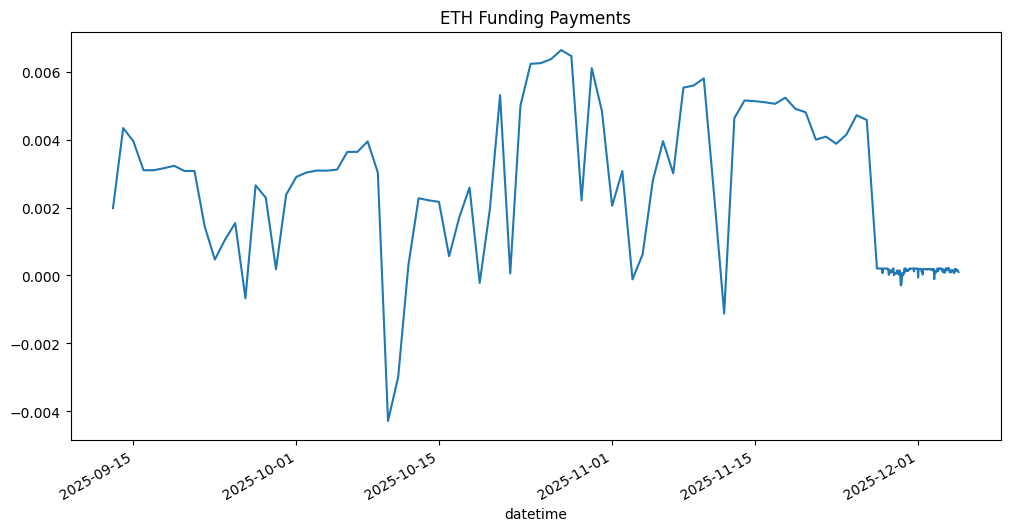

In [ ]:
#|eval: false
funding_df[funding_df['coin'] == 'ETH']['usdc'].plot(figsize=(12, 6), title="ETH Funding Payments")

<Axes: title={'center': 'ETH Funding Rate'}, xlabel='datetime'>

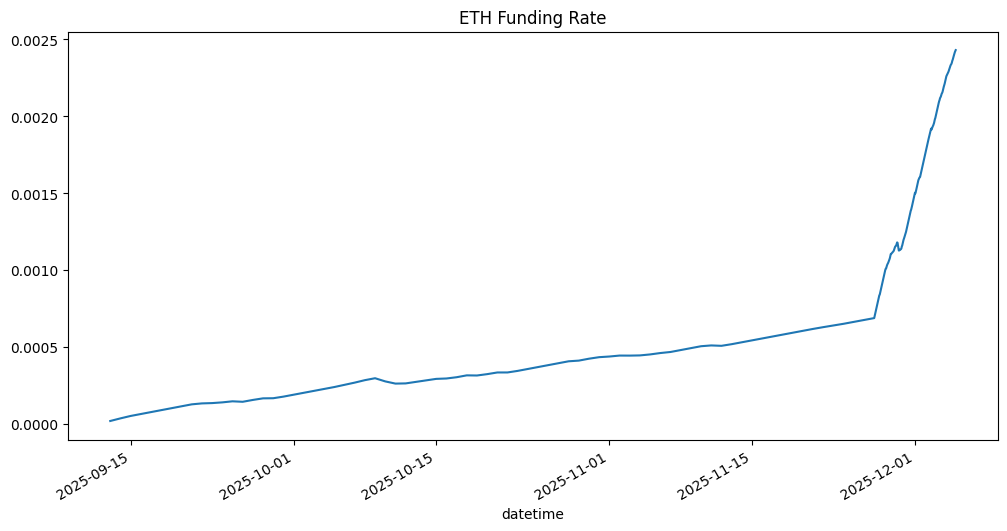

In [ ]:
#| eval: false
funding_df[funding_df['coin'] == 'ETH']['fundingRate'].cumsum().plot(figsize=(12, 6), title="ETH Funding Rate")

<Axes: title={'center': 'Cumsum Funding Received/Paid'}, xlabel='datetime'>

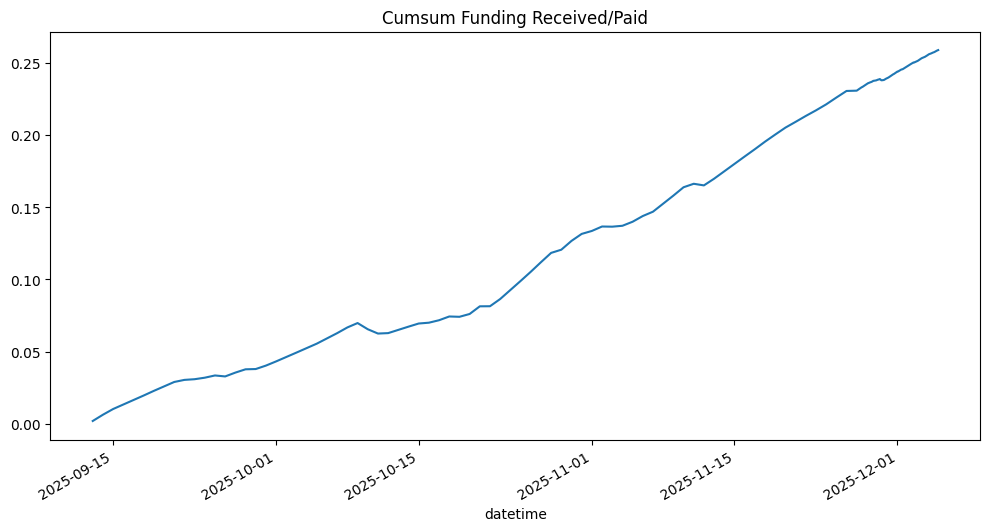

In [ ]:
#| eval: false
funding_df[funding_df['coin'] == 'ETH']['usdc'].cumsum().plot(figsize=(12, 6), title="Cumsum Funding Received/Paid")

## get_user_ledger_updates function

In [0]:
#| echo: false
#| output: asis
show_doc(get_user_ledger_updates)

---

[source](https://github.com/silvaac/token_data/blob/main/token_data/hyper_account.py#L248){target="_blank" style="float:right; font-size:smaller"}

### get_user_ledger_updates

```python
def get_user_ledger_updates(
    address, start_date:NoneType=None, end_date:NoneType=None, lookback:int=30, info:NoneType=None,
    include_hash:bool=False
):
```

*Retrieves user non-funding ledger updates from Hyperliquid and returns as a DataFrame.*

This function captures account events like deposits, withdrawals, transfers, and other
non-funding related balance changes.

Args:
    address (str): User's wallet address
    start_date (str, optional): Start date as string. Can be:
        - ISO format: "2024-01-15T10:30:00Z" or "2024-01-15T10:30:00"
        - Date only: "2024-01-15"
        - If None, calculated from lookback. Defaults to None.
    end_date (str, optional): End date as string (same formats as start_date).
        - If None, uses current UTC time. Defaults to None.
    lookback (int, optional): Number of days to look back from end_date if start_date is None.
        Defaults to 30.
    info (Info, optional): Hyperliquid Info client. If None, creates a new one.
    include_hash (bool, optional): If True, includes 'hash' column with transaction hashes.
        Defaults to False.

Returns:
    pandas.DataFrame: DataFrame containing ledger update data indexed by datetime with columns:
        - type: Type of ledger update (e.g., 'deposit', 'withdraw', 'accountClassTransfer')
        - usdc: Amount in USDC
        - toPerp: For transfers, whether transfer was to perpetual account (True) or from (False)
        - hash: Transaction hash (only if include_hash=True)
    Returns None if no ledger updates found or error occurs.

Examples:
    # Get last 30 days of ledger updates
    ledger_df = get_user_ledger_updates(address, info=info)

    # Get ledger updates for specific date range
    ledger_df = get_user_ledger_updates(address, 
                                       start_date="2024-01-01",
                                       end_date="2024-01-31",
                                       info=info)

    # Calculate total deposits
    deposits = ledger_df[ledger_df['type'] == 'deposit']['usdc'].sum()

    # Calculate total withdrawals
    withdrawals = ledger_df[ledger_df['type'] == 'withdraw']['usdc'].sum()

    # Get all transfers to perpetual account
    to_perp = ledger_df[(ledger_df['type'] == 'accountClassTransfer') & 
                       (ledger_df['toPerp'] == True)]

Notes:
    - DataFrame is indexed by datetime (converted from milliseconds)
    - All numeric columns are converted to float for calculations
    - Sorted by datetime in ascending order
    - Does not include funding payments (use get_user_funding_history for that)
    - Common transaction types:
        * 'deposit': Deposits to account
        * 'withdraw': Withdrawals from account
        * 'accountClassTransfer': Transfers between spot and perpetual accounts

In [ ]:
#| eval: false
# Test the function
ledger_df = get_user_ledger_updates(address, info=info, lookback=90)

if ledger_df is not None:
    print(f"Total Ledger Updates: {len(ledger_df)}")
    print(f"\nDate Range: {ledger_df.index.min()} to {ledger_df.index.max()}")
    
    print(f"\nLedger Updates by Type:")
    print(ledger_df.groupby('type').size().sort_values(ascending=False))
    
    print(f"\nSummary by Type:")
    summary = ledger_df.groupby('type')['usdc'].agg(['sum', 'count', 'mean'])
    summary.columns = ['Total USDC', 'Count', 'Avg Amount']
    print(summary)
    
    # Calculate net deposits/withdrawals
    deposits = ledger_df[ledger_df['type'] == 'deposit']['usdc'].sum()
    withdrawals = ledger_df[ledger_df['type'] == 'withdraw']['usdc'].sum()
    print(f"\nTotal Deposits: ${deposits:.2f}")
    print(f"Total Withdrawals: ${withdrawals:.2f}")
    print(f"Net Deposits: ${deposits - withdrawals:.2f}")
    
    # Show transfers between accounts
    transfers = ledger_df[ledger_df['type'] == 'accountClassTransfer']
    if len(transfers) > 0:
        to_perp = transfers[transfers['toPerp'] == True]['usdc'].sum()
        from_perp = transfers[transfers['toPerp'] == False]['usdc'].sum()
        print(f"\nTransfers to Perpetual: ${to_perp:.2f}")
        print(f"Transfers from Perpetual: ${from_perp:.2f}")

Total Ledger Updates: 5

Date Range: 2025-09-13 13:29:51.820000 to 2025-11-01 13:08:31.024000

Ledger Updates by Type:
type
deposit                 3
accountClassTransfer    2
dtype: int64

Summary by Type:
                      Total USDC  Count  Avg Amount
type                                               
accountClassTransfer       35.00      2       17.50
deposit                    91.26      3       30.42

Total Deposits: $91.26
Total Withdrawals: $0.00
Net Deposits: $91.26

Transfers to Perpetual: $0.00
Transfers from Perpetual: $35.00


Deposit and transfers between perp and spot accounts has been checked against Hyperliquid "Portfolio" page. Values are consistent with the Hyperliquid Portfolio page.

In [ ]:
#| eval: false
ledger_df

,type,usdc,toPerp
datetime,,,
2025-09-13 13:29:51.820,deposit,30.00,None
2025-09-13 13:31:44.867,accountClassTransfer,15.00,False
2025-10-21 00:41:50.464,deposit,31.90,None
2025-10-21 00:45:18.649,accountClassTransfer,20.00,False
2025-11-01 13:08:31.024,deposit,29.36,None


In [ ]:
#[method for method in dir(info) if 'user' in method.lower()]

In [ ]:
#| eval: false
# Check the help documentation for user_fees
#help(info.user_fees)
#help(info.user_state)

## get_account_summary function

In order to validate these results, you can use the Hyperliquid Portfolio. Log-in Hyperliquid and navegate to the "Portfolio" page/tab.

In [0]:
#| echo: false
#| output: asis
show_doc(get_account_summary)

---

[source](https://github.com/silvaac/token_data/blob/main/token_data/hyper_account.py#L389){target="_blank" style="float:right; font-size:smaller"}

### get_account_summary

```python
def get_account_summary(
    address, info:NoneType=None, lookback_days:int=3650
):
```

*Retrieves a comprehensive account summary including deposits, withdrawals, and current value.*

Args:
    address (str): User's wallet address
    info (Info, optional): Hyperliquid Info client. If None, creates a new one.
    lookback_days (int, optional): Number of days to look back for ledger history. 
        Defaults to 3650 (~10 years).

Returns:
    dict: Dictionary containing:
        - total_deposits (float): Total amount deposited in USDC
        - total_withdrawals (float): Total amount withdrawn in USDC
        - net_deposits (float): Net deposits (deposits - withdrawals) in USDC
        - current_value (float): Current total account value in USDC
        - spot_value (float): Value in spot account in USDC
        - perp_margin (float): Margin in perpetual account in USDC
        - perp_position_value (float): Current notional value of perpetual positions in USDC
        - total_pnl (float): Total profit/loss (current_value - net_deposits)
        - pnl_percentage (float): P&L as percentage of net deposits
        - unrealized_pnl (float): Unrealized P&L from open perpetual positions
    Returns None if error occurs.

Examples:
    # Get account summary
    summary = get_account_summary(address, info=info)

    if summary:
        print(f"Net Deposits: ${summary['net_deposits']:,.2f}")
        print(f"Current Value: ${summary['current_value']:,.2f}")
        print(f"Total P&L: ${summary['total_pnl']:,.2f} ({summary['pnl_percentage']:.2f}%)")

Notes:
    - All values are in USDC
    - P&L includes both realized and unrealized gains/losses
    - Current value = spot balance + perp margin + current position values
    - Uses current market prices from info.all_mids() to value positions
    - Requires access to user_state, spot_user_state, and ledger updates

Deposit history is correct, same as previous function. 

Spot balance is correct and it is the sum of USDC balance and the spot position in USDC at the time the function is called.

Perp balance is correct and it is the sum of the USDC balance and the perp position in USDC at the time the function is called.

In [ ]:
#| eval: false
# Test the corrected account summary function
summary,df = get_account_summary(address, info=info)

if summary:
    print("=" * 60)
    print("ACCOUNT SUMMARY")
    print("=" * 60)
    print(f"When(UTC):                {summary['when']}")
    print(f"\nDeposit/Withdrawal History:")
    print(f"  Total Deposits:    ${summary['total_deposits']:,.2f}")
    print(f"  Total Withdrawals: ${summary['total_withdrawals']:,.2f}")
    print(f"  Net Deposits:      ${summary['net_deposits']:,.2f}")
    
    print(f"\nCurrent Account Value:")
    print(f"  Total Value:       ${summary['current_value']:,.2f}")
    print(f"    Spot Balance:    ${summary['spot_value']:,.2f}")
    print(f"    Perp Balance:     ${summary['perp_value']:,.2f}")
    
    print(f"\nPerpetual Positions:")
    print(f"  Position Value: ${summary['perp_position_value']:,.2f}")
    print(f"  Unrealized perp PnL:    ${summary['unrealized_pnl']:,.2f}")
    print(f"  Cash in Perp accout:    ${summary['cash_in_perp']:,.2f}")
   
    print(f"\nProfit/Loss:")
    print(f"  Total P&L:         ${summary['total_pnl']:,.2f}")
    print(f"  P&L Percentage:    {summary['pnl_percentage']:.2f}%")
    print("=" * 60)

PnL: {'@151': -6.41, 'ETH': 6.02}
ACCOUNT SUMMARY
When(UTC):                2025-12-05 00:30:28

Deposit/Withdrawal History:
  Total Deposits:    $91.26
  Total Withdrawals: $0.00
  Net Deposits:      $91.26

Current Account Value:
  Total Value:       $91.10
    Spot Balance:    $28.57
    Perp Balance:     $62.53

Perpetual Positions:
  Position Value: $16.97
  Unrealized perp PnL:    $1.87
  Cash in Perp accout:    $45.55

Profit/Loss:
  Total P&L:         $-0.16
  P&L Percentage:    -0.18%


The next data frame contains the positions of the account. Notice that total P&L is the sum of the spot positions and the perpetual positions together with the funding rate paid. The underlized P&L for the perpertual positions is a downloaded directly from the Hyperliquid and so it is the total P&L. However, the spot P&L can not be downloaded directly from the Hyperliquid. The function calculates this by using the fills the the curretn mid price.

In [ ]:
#|eval: false
df

,coin,signed_position,price,current_usdc_value,unrealized_pnl,leverage,ROE,liquidation_px,max_leverage,cum_funding,asset_type,datetime
0,USDC,11.285100,1.00,11.285100,0.000000,1.0,0.00000,0.000000,0.0,0.000000,spot,2025-12-05 00:30:28.972
1,@151,0.005496,3145.55,17.288415,-6.410000,1.0,0.00000,0.000000,0.0,0.000000,spot,2025-12-05 00:30:28.972
2,ETH,-0.005400,3143.15,16.973010,1.873973,1.0,0.09943,14433.467502,25.0,-0.258885,perp,2025-12-05 00:30:28.972


## Trade

TODO ....